# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [16]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
# Load the dataset
df = pd.read_csv("humidity.csv")
print("Dataset Info:")
df.info()
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB

First 5 rows:
   sensor_id     lat     lon  pressure  temperature  humidity
0       2266  42.738  23.272  95270.27        23.46     62.48
1       2292  42.663  23.273  94355.83        23.06     59.46
2       3096  42.700  23.360  95155.81        26.53     44.38
3       3428  42.624  23.406  94679.57        28.34     38.28
4       3472  42.669  23.318  94327.88        26.31     46.37


## Exploratory Data Analysis


In [18]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())



Missing values in each column:
sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64

Summary Statistics:
           sensor_id            lat            lon       pressure  \
count  701548.000000  701548.000000  701548.000000  701548.000000   
mean     2835.419842      42.679722      23.333739   94965.292500   
std       798.018890       0.025568       0.039365    2577.210945   
min      1764.000000      42.622000      23.240000       0.000000   
25%      2224.000000      42.665000      23.310000   94528.017500   
50%      2323.000000      42.685000      23.332000   95005.480000   
75%      3474.000000      42.694000      23.360000   95405.132500   
max      4661.000000      42.738000      23.419000  164926.750000   

         temperature       humidity  
count  701548.000000  701548.000000  
mean       24.754990      48.348949  
std        14.013001      20.907247  
min      -145.120000       0.000000  
25%        20.630000

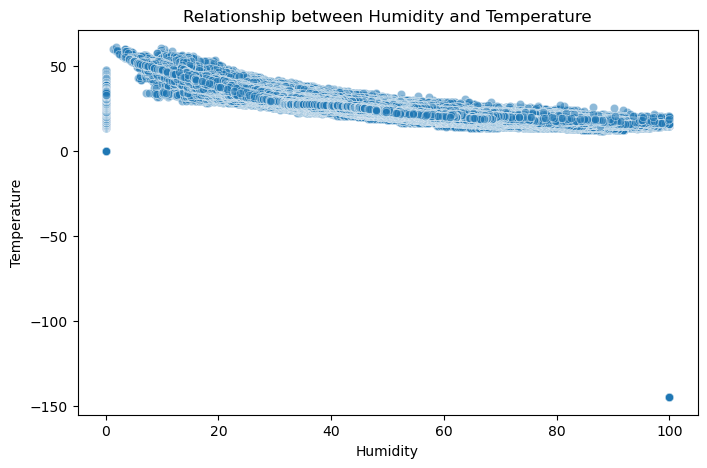

In [20]:
# Scatter plot to observe relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='humidity', y='temperature', data=df, alpha=0.5)
plt.title('Relationship between Humidity and Temperature')
plt.xlabel('Humidity')
plt.ylabel('Temperature')
plt.show()

## Data Preprocessing

In [21]:
# Drop any rows with missing values
df = df.dropna()

# Define features and target
# X is our feature (humidity), must be a 2D array/DataFrame
X = df[['humidity']] 
# y is our target (temperature), a 1D Series
y = df['temperature']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [22]:
# Linear Regression
# Initialize the model
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)

# Predict
# Make predictions using the testing set
y_pred = model.predict(X_test)

## Evaluation



--- Model Evaluation ---
Mean Squared Error (MSE): 144.08
R-squared (R2) Score: 0.26


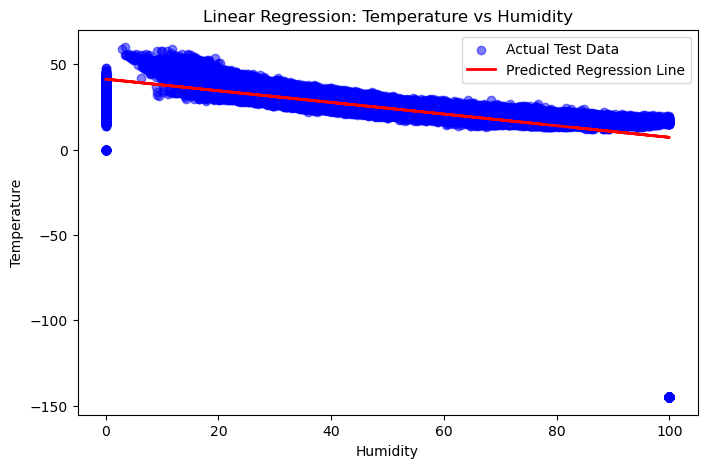

In [23]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Plot the regression line over the test data to see how it fits
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Regression Line')
plt.title('Linear Regression: Temperature vs Humidity')
plt.xlabel('Humidity')
plt.ylabel('Temperature')
plt.legend()
plt.show()

## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.
